<h2> <strong> <span style="color: lightgreen"> Polars vs Pandas 🐼
</span>
</strong>
</h2>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



- **Linkedin Jobs and Skills:**
  - Pata comparar el rendimiento de las paqueterias Pandas y Polars se utiliza el data set de empleos de Linkedin que tiene una dimensión de 1,348,454  filas y 14 columnas.
  - Sitio web: [Kaggle]( https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024)







* <h3> <strong> <span style="color: darkgreen"> Carga de datos CSV
</strong>
</h4>

In [3]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Reading
path_data_link = fr'/content/drive/MyDrive/cursos-para-dictar/UDM/05_clase/linkedin_job_postings.csv'

In [4]:
%%time
df_pd_read = pd.read_csv(path_data_link) # pandas

CPU times: user 8.79 s, sys: 1.29 s, total: 10.1 s
Wall time: 16.5 s


In [5]:
%%time
df_pl_read = pl.read_csv(path_data_link) # polars

CPU times: user 2.21 s, sys: 860 ms, total: 3.07 s
Wall time: 2.12 s


* `-n10` : se repite la ejecución 10 veces por cada ciclo

* `-r1` : ejecuta 1 ciclo en total

* `-o` : guarda el resultado de la medición en una variable

In [6]:
%%time
pd_time_read_csv = %timeit -n10 -r1 -o df_pd_read_csv= pd.read_csv(path_data_link)

10.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
CPU times: user 1min 25s, sys: 10.2 s, total: 1min 35s
Wall time: 1min 41s


In [7]:
%%time
pl_time_read_csv = %timeit -n10 -r1 -o df_pl_read_csv = pl.read_csv(path_data_link)

2.22 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
CPU times: user 25.1 s, sys: 4.55 s, total: 29.7 s
Wall time: 22.2 s


In [16]:
df_pl_read.head(2)

job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,In USA
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""https://www.linkedin.com/jobs/…","""2024-01-21 07:12:29.00256+00""","""t""","""t""","""f""","""Account Executive - Dispensing…","""BD""","""San Diego, CA""","""2024-01-15""","""Coronado""","""United States""","""Color Maker""","""Mid senior""","""Onsite""","""Yes"""
"""https://www.linkedin.com/jobs/…","""2024-01-21 07:39:58.88137+00""","""t""","""t""","""f""","""Registered Nurse - RN Care Man…","""Trinity Health MI""","""Norton Shores, MI""","""2024-01-14""","""Grand Haven""","""United States""","""Director Nursing Service""","""Mid senior""","""Onsite""","""Yes"""


In [17]:
print(df_pl_read.columns)

['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type', 'In USA']


In [8]:
# Función para graficar

def bar_plot(pl_time, pd_time):
    data = {'Library': ['Polars', 'Pandas'],
            'Average Time (seconds)': [pl_time, pd_time]}
    df = pd.DataFrame(data)
    plt.figure(figsize=(8, 6))
    custom_palette = ["royalblue", "darkgrey"]
    sns.set(style="whitegrid")
    ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)
    ax.set_title('Tiempo promedio de ejecución')
    ax.set_xlabel('Librería')
    ax.set_ylabel('Tiempo promedio (segundos)')

    # Annotate bars with values
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

<ipython-input-8-f745cac09d91>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)


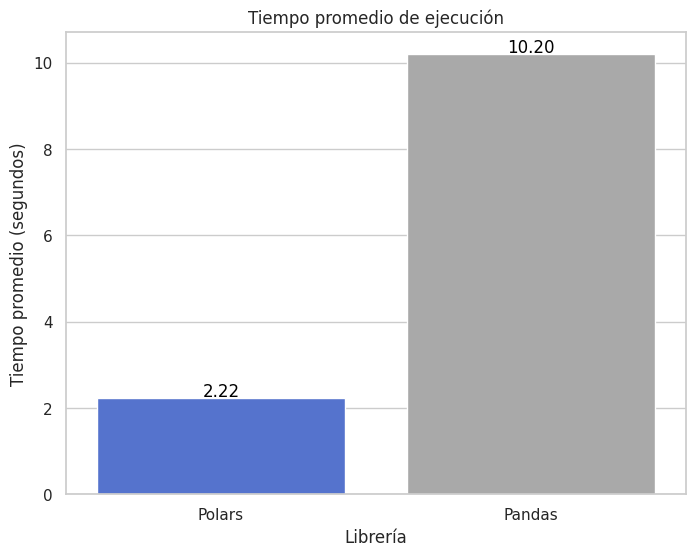

In [9]:
bar_plot(pl_time_read_csv.average, pd_time_read_csv.average)

* <h3> <strong> <span style="color: orange"> Filtros
</strong>
</h4>

In [10]:
#Filter performing
pd_time_filter = %timeit -n10 -r1 -o df_pd_read.query('job_type == "Remote"')
pl_time_filter = %timeit -n10 -r1 -o df_pl_read.filter(pl.col('job_type') == 'Remote')

34.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
23.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


<ipython-input-8-f745cac09d91>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)


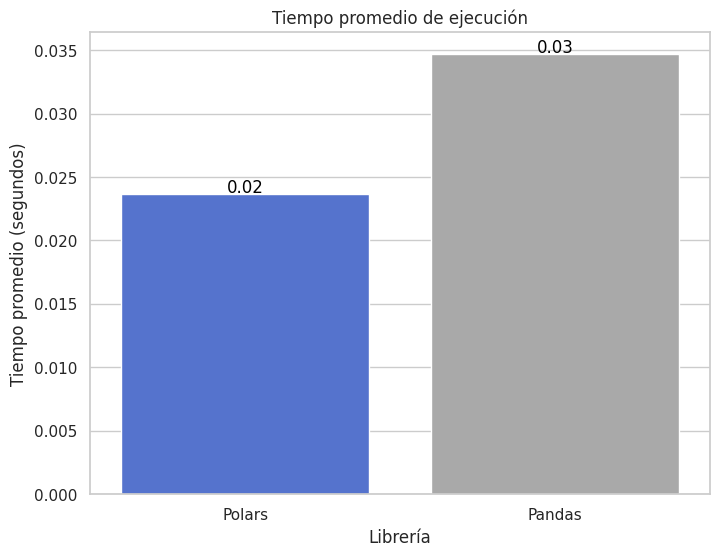

In [11]:
bar_plot(pl_time_filter.average, pd_time_filter.average)

* <h3> <strong> <span style="color: orange"> Creación de nuevas variables
</strong>
</h4>

In [14]:
#Polars

df_pl_read = df_pl_read.with_columns(
    pl.when(pl.col("search_country") == "United States")
      .then(pl.lit("Yes"))
      .otherwise(pl.lit("No"))
      .alias("In USA")
)

#Pandas
import numpy as np

df_pd_read['In USA'] = np.where(
    df_pd_read['search_country'] == "United States",
    'Yes',
    'No'
)

In [19]:
#Creating new features
pl_new_var = %timeit -n10 -r1 -o df_pl_new_var = df_pl_read.with_columns(pl.when(pl.col("search_country") == "United States").then(pl.lit("Yes"))  # 🔍 lo marcamos como valor literal.otherwise(pl.lit("No"))
    .alias("In USA")
).collect()
pd_new_var = %timeit -n10 -r1 -o df_pd_read['In USA'] = pd.np.where(df_pd_read['search_country'] == "United States" , 'Yes', 'No')

IndentationError: unexpected indent (<ipython-input-19-0551500e5f4e>, line 3)

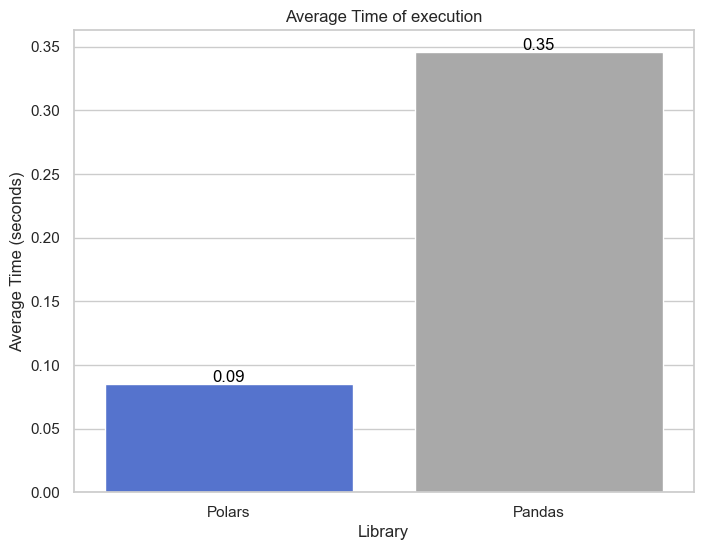

In [ ]:
bar_plot(pl_new_var.average, pd_new_var.average)

* <h3> <strong> <span style="color: orange"> Agrupamiento y funciones de agregación
</strong>
</h4>

In [ ]:
#Polars
df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))
#Pandas
df_grouped_pd = df_pd_read.groupby('job_level').agg(count_job_level = ('job_level', 'count'))

C:\Users\diego.0661471\AppData\Local\Temp\ipykernel_38556\1399631349.py:2: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))


<magic-timeit>:1: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.


124 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
137 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


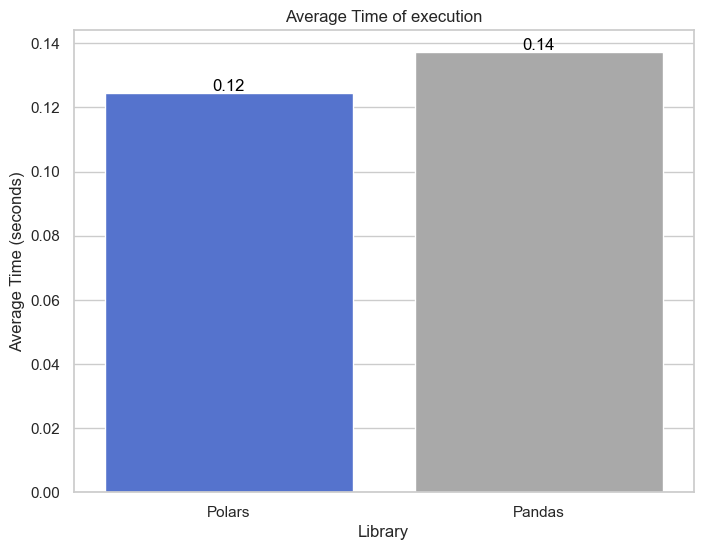

In [ ]:
#Grouping and agregation
pl_groupby = %timeit -n10 -r1 -o df_grouped_pl = df_pl_read.groupby('job_level').agg(pl.count('job_level').alias('count_job_level'))
pd_groupby = %timeit -n10 -r1 -o df_pd_read.groupby('job_level').agg(count_job_level = ('job_level', 'count'))
#Plot
bar_plot(pl_groupby.average, pd_groupby.average)